# Batch Quality Report

The first two notebooks work one file at a time. This one runs the quality checks
over an **entire directory** of recordings and summarizes the result, which is the
usual shape of the problem after a field season: a few hundred files land on disk
and the question is which of them are usable.

It uses the batch helpers in `soundsanity`:

| Function | Purpose |
| --- | --- |
| `find_audio_files` | Recursively collect audio files under a directory |
| `analyze_directory` | Run `analyze_recording` over all of them, in parallel |
| `flatten_report` | Collapse a nested report into one flat row (CSV / DataFrame) |
| `summarize` | Count statuses overall and per folder |

The same analysis is available from the shell as `soundsanity-report`.

### 1. Imports and setup

In [37]:
import essentia.standard as es
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import soundsanity as ss

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["figure.dpi"] = 110

AUDIO_DIR = "../audio_examples"

### 2. Discovering recordings

`find_audio_files` walks the tree and keeps anything with a known audio extension,
matched case-insensitively — which matters here, since the field recorders write
`.WAV` in upper case while the curated examples are lower case.

In [38]:
files = ss.find_audio_files(AUDIO_DIR)

print(f"Found {len(files)} audio files")
print(f"Extensions present: {sorted({p.suffix for p in files})}")
files[:5]

Found 68 audio files
Extensions present: ['.WAV', '.mp3', '.wav']


[PosixPath('../audio_examples/catedral_1.mp3'),
 PosixPath('../audio_examples/catedral_2.mp3'),
 PosixPath('../audio_examples/clean/20230211_110222.WAV'),
 PosixPath('../audio_examples/clean/20230212_180055.WAV'),
 PosixPath('../audio_examples/clicky/20230211_150000.WAV')]

### 3. Running the batch

`analyze_directory` runs `analyze_recording` on every file. A few things it handles
that a hand-written loop usually doesn't:

- **Parallelism.** `jobs` defaults to the CPU count (capped at 8).
- **Bad files.** A recording that won't decode comes back with `status="ERROR"` and
  an `error` message instead of killing the run. Use `on_error="skip"` to drop them
  or `on_error="raise"` to fail loudly.
- **Provenance.** Each result gains `path` and `group`, so a file can be traced back
  to the folder it came from.

Results keep the same nested shape `analyze_recording` returns.

In [39]:
def progress(done, total):
    if done % 10 == 0 or done == total:
        print(f"  analyzed {done}/{total}")

results = ss.analyze_directory(AUDIO_DIR, progress=progress)
results[0]

  analyzed 10/68
  analyzed 20/68
  analyzed 30/68
  analyzed 40/68
  analyzed 50/68
  analyzed 60/68
  analyzed 68/68


{'file_name': 'catedral_1.mp3',
 'duration': 66.40798185941043,
 'clicks': {'clicks_count': 0,
  'clicks_rate': 0.0,
  'click_timestamps': [],
  'is_clicky': False},
 'saturation': {'saturation_intervals': [],
  'saturation_duration': 0.0,
  'saturation_ratio': 0.0,
  'is_saturated': False},
 'silence': {'silence_ratio': 0.019576997028491524, 'is_silent': False},
 'noise': {'rms_db': -43.55065046099418,
  'noise_floor_db': -47.857394200276,
  'active_level_db': -41.23291645896132,
  'snr_db': 6.624477741314678,
  'is_noisy': True},
 'status': 'NOISY',
 'issues': ['Recording is noisy (noise floor -47.9 dB, SNR 6.6 dB)'],
 'path': 'catedral_1.mp3',
 'group': '(root)'}

### 4. Results as a table

`flatten_report` collapses the nested report into a single row per file, which is
what you want for a DataFrame or a CSV.

In [40]:
df = pd.DataFrame(ss.flatten_report(r) for r in results)
df = df[["path", "group", "duration_s", "status", "noise_floor_db",
         "snr_db", "silence_ratio", "clicks_rate", "saturation_ratio"]]

df.head(10)

,path,group,duration_s,status,noise_floor_db,snr_db,silence_ratio,clicks_rate,saturation_ratio
0,catedral_1.mp3,(root),66.407982,NOISY,-47.857394,6.624478,0.019577,0.000000,0.000000
1,catedral_2.mp3,(root),52.258730,CLEAN,-46.088537,14.214570,0.045081,0.057407,0.000000
2,clean/20230211_110222.WAV,clean,157.999977,CLEAN,-45.158639,14.332718,0.000000,0.018987,0.000000
3,clean/20230212_180055.WAV,clean,244.999977,CLEAN,-47.487071,15.416138,0.000711,0.012245,0.000000
4,clicky/20230211_150000.WAV,clicky,299.999977,SATURATED,-11.902888,9.177621,0.000000,8.580001,0.085459
5,clicky/20230211_180000.WAV,clicky,299.999977,SATURATED,-26.779144,23.496278,0.000000,1.760000,0.024449
6,deshielo.mp3,(root),84.909592,CLEAN,-61.971500,11.630495,0.906904,0.000000,0.000000
7,deshielo.wav,(root),84.909592,CLEAN,-61.751330,11.614917,0.901982,0.635971,0.000000
8,el_refugio.mp3,(root),166.249887,NOISY,-53.060632,6.975897,0.510788,0.000000,0.000000
9,el_refugio.wav,(root),166.249887,NOISY,-52.793583,6.974072,0.470707,0.000000,0.000000


Sorting by noise floor shows the loudest-background files first:

In [41]:
df.sort_values("noise_floor_db", ascending=False).head(8)

,path,group,duration_s,status,noise_floor_db,snr_db,silence_ratio,clicks_rate,saturation_ratio
24,noisy/BCAA1_20211130_170000.wav,noisy,299.999977,NOISY,-6.095286,0.419633,0.0,0.006667,0.0
18,noisy/BCAA1_20211130_110000.wav,noisy,299.999977,NOISY,-6.095286,0.419633,0.0,0.006667,0.0
16,noisy/BCAA1_20211130_090000.wav,noisy,299.999977,NOISY,-6.095286,0.419633,0.0,0.006667,0.0
15,noisy/BCAA1_20211130_080000.wav,noisy,299.999977,NOISY,-6.095286,0.419633,0.0,0.006667,0.0
14,noisy/BCAA1_20211130_070000.wav,noisy,299.999977,NOISY,-6.095286,0.419633,0.0,0.006667,0.0
13,noisy/BCAA1_20211126_200000.wav,noisy,299.999977,NOISY,-6.095286,0.419633,0.0,0.006667,0.0
19,noisy/BCAA1_20211130_120000.wav,noisy,299.999977,NOISY,-6.095286,0.419633,0.0,0.006667,0.0
20,noisy/BCAA1_20211130_130000.wav,noisy,299.999977,NOISY,-6.095286,0.419633,0.0,0.006667,0.0


### 5. Summary

`summarize` counts statuses overall and per folder.

In [42]:
stats = ss.summarize(results)

print(f"Total files: {stats['total']}\n")
for status, count in stats["by_status"].items():
    print(f"  {status:<10} {count:>3}  ({count / stats['total']:.0%})")

Total files: 68

  NOISY       34  (50%)
  SATURATED   22  (32%)
  CLEAN        7  (10%)
  SILENT       5  (7%)


### 6. Folder label vs. detected status

The subfolders in `audio_examples/` are human labels — someone filed each recording
under what they believed was wrong with it. Crossing those labels against what the
detectors actually report is the fastest way to see whether the thresholds are
calibrated for this material.

Read it as an agreement matrix: a folder whose files all land in one column is a
category the detectors handle consistently.

In [43]:
STATUS_ORDER = ["CLEAN", "SILENT", "NOISY", "CLICKY", "SATURATED", "ERROR"]

matrix = (
    pd.crosstab(df["group"], df["status"])
    .reindex(columns=[s for s in STATUS_ORDER if s in set(df["status"])], fill_value=0)
)
matrix

status,CLEAN,SILENT,NOISY,SATURATED
group,,,,
(root),5,0,9,0
clean,2,0,0,0
clicky,0,0,0,2
noisy,0,0,25,0
silence,0,5,0,0
wind,0,0,0,20


The same matrix as a heatmap. It uses a single-hue sequential ramp — lightest means
"no files", darkest means "most files" — so magnitude is carried by lightness alone
rather than by hue.

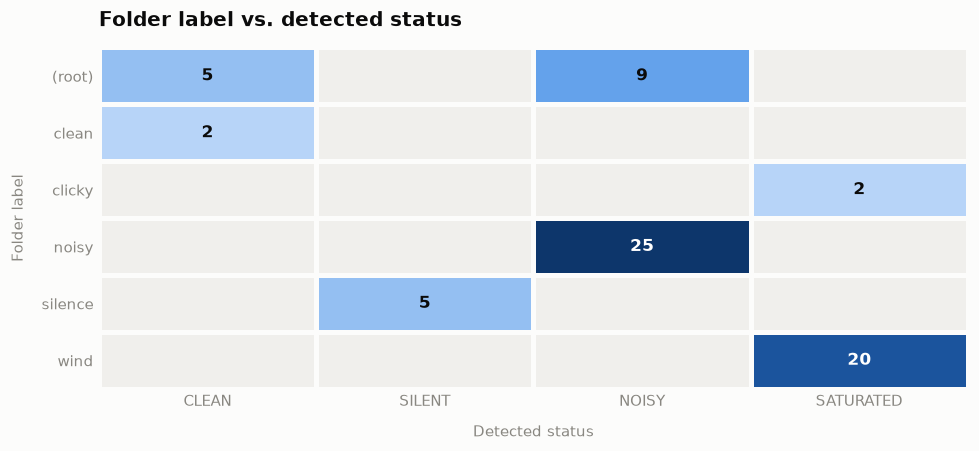

In [44]:
from matplotlib.colors import LinearSegmentedColormap

# Single-hue sequential ramp: light (near zero) to dark (the largest count).
BLUE_RAMP = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
SURFACE, INK, MUTED = "#fcfcfb", "#0b0b0b", "#898781"

cmap = LinearSegmentedColormap.from_list("ss_blue", BLUE_RAMP)
# Empty cells recede to a neutral so "no files" never reads as a small count.
cmap.set_bad("#f0efec")

counts = matrix.to_numpy()
shaded = np.ma.masked_where(counts == 0, counts)

fig, ax = plt.subplots(figsize=(9, 4.2))
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

# A 2px surface-colored gap between cells keeps adjacent blocks from merging.
ax.pcolormesh(shaded, cmap=cmap, vmin=0, vmax=counts.max(),
              edgecolors=SURFACE, linewidth=2)

for row in range(counts.shape[0]):
    for col in range(counts.shape[1]):
        value = counts[row, col]
        if value == 0:
            continue
        # Flip the label to white once the cell is dark enough to swallow black ink.
        shade = value / counts.max()
        ax.text(col + 0.5, row + 0.5, str(value),
                ha="center", va="center", fontsize=11, fontweight="bold",
                color="#ffffff" if shade > 0.55 else INK)

ax.set_xticks(np.arange(counts.shape[1]) + 0.5, matrix.columns, fontsize=10)
ax.set_yticks(np.arange(counts.shape[0]) + 0.5, matrix.index, fontsize=10)
ax.set_xlabel("Detected status", fontsize=10, color=MUTED, labelpad=10)
ax.set_ylabel("Folder label", fontsize=10, color=MUTED, labelpad=10)
ax.set_title("Folder label vs. detected status", fontsize=13, fontweight="bold",
             color=INK, pad=14, loc="left")
ax.invert_yaxis()
ax.tick_params(length=0, colors=MUTED)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

`clean/`, `noisy/` and `silence/` land in their matching columns. The interesting
row is **`wind/`, which comes back `SATURATED`** — along with `clicky/`.

That is not a misdiagnosis; it is a more specific one. Those recordings are clipped.

In [45]:
# Crest factor is peak-to-RMS in dB. A healthy field recording sits at 12-20 dB;
# a heavily clipped one collapses toward 3 dB, because every peak is flattened.
def clip_stats(path):
    audio = es.MonoLoader(filename=path, sampleRate=44100)()
    peak = float(np.max(np.abs(audio)))
    rms = float(np.sqrt(np.mean(audio.astype(np.float64) ** 2)))
    return pd.Series({
        "crest_db": 20 * np.log10(peak / rms),
        "pct_at_full_scale": float(np.mean(np.abs(audio) > 0.99)) * 100,
    })

sample_per_group = df.sort_values("path").groupby("group").first().reset_index()
evidence = sample_per_group[["group", "path", "status"]].join(
    sample_per_group["path"].apply(lambda p: clip_stats(f"{AUDIO_DIR}/{p}"))
)
evidence.round(2)

,group,path,status,crest_db,pct_at_full_scale
0,(root),catedral_1.mp3,NOISY,31.80,0.00
1,clean,clean/20230211_110222.WAV,CLEAN,32.83,0.00
2,clicky,clicky/20230211_150000.WAV,SATURATED,5.67,11.44
3,noisy,noisy/20230211_190000.WAV,NOISY,14.85,0.00
4,silence,silence/20230211_050000.WAV,SILENT,13.68,0.00
5,wind,wind/20231214_052000.WAV,SATURATED,5.35,10.46


The `wind/` and `clicky/` samples are pinned against full scale for a large share of
their duration, with crest factors down around 4 dB. Everything else has no samples
at full scale at all.

**Why clipping shows up as clicks.** Clipping flattens each peak against the rail,
and every flat top has a sharp corner at each end. `ClickDetector` works by LPC
inverse filtering — predicting each sample from its predecessors and flagging large
prediction errors — and a corner is precisely what a linear predictor cannot follow.
So each clipped peak produces a residual spike indistinguishable from a click. Take a
clean recording and add nothing but gain, and the click rate climbs with the clipping:
0.10 clicks/sec at 0 dB, 3.6 at +20 dB, 11.9 at +30 dB, 15.9 at +40 dB. No clicks were
ever inserted.

These files did read `CLICKY` until `saturation_min_duration` was lowered from 5.0 ms
to 1.0 ms. At 44.1 kHz, 5 ms means a clipped run must span 220 consecutive samples to
register, and the runs here top out around 110 — so `SaturationDetector` saw nothing
while `ClickDetector` picked up the side effect and named the wrong cause. Section 8
reproduces that.

### 7. Inspecting a single file

The batch narrows things down; `plot_quality_report` explains one file. Any entry
from `analyze_directory` can be passed straight to it.

silence/20230211_050000.WAV  ->  SILENT
  - Recording is silent (silence ratio 99.26%)
  - Recording is noisy (noise floor -53.0 dB, SNR 1.7 dB)


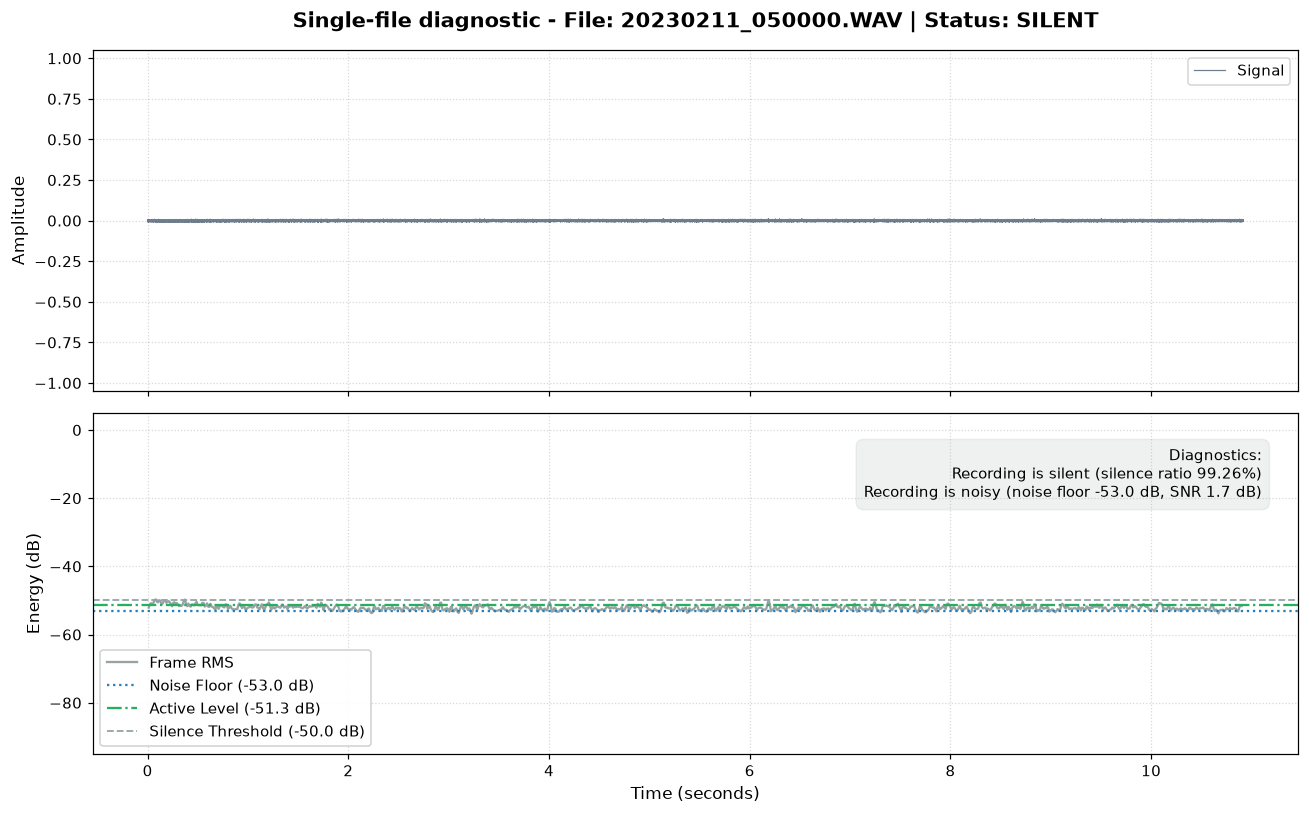

In [46]:
# The shortest flagged recording, so the waveform stays legible — a five-minute
# file at full amplitude just renders as a solid block.
flagged = df[df["status"] != "CLEAN"].sort_values("duration_s")
chosen = flagged.iloc[0]
report = next(r for r in results if r["path"] == chosen["path"])

print(f"{report['path']}  ->  {report['status']}")
for issue in report["issues"]:
    print(f"  - {issue}")

audio = es.MonoLoader(filename=f"{AUDIO_DIR}/{report['path']}", sampleRate=44100)()
fig, axs = ss.plot_quality_report(audio, 44100, report, title="Single-file diagnostic")
plt.show()

### 8. Trying different thresholds

Every check reads its cutoffs from `DEFAULT_CONFIG`, and `analyze_directory` forwards
a `config` override to each file. That makes threshold tuning something you can
measure across the whole corpus instead of guessing at.

To see why `saturation_min_duration` was lowered to 1.0 ms, put it back to the 5.0 ms
it used to be and re-run:

In [47]:
retuned = ss.analyze_directory(AUDIO_DIR, config={"saturation_min_duration": 5.0})
retuned_df = pd.DataFrame(ss.flatten_report(r) for r in retuned)

comparison = pd.DataFrame({
    "default (1.0 ms)": df.set_index("path")["status"],
    "min_duration=5.0 ms": retuned_df.set_index("path")["status"],
})
changed = comparison[comparison.iloc[:, 0] != comparison.iloc[:, 1]]

print(f"{len(changed)} of {len(comparison)} files changed status\n")
changed.groupby(list(comparison.columns)).size()

22 of 68 files changed status



default (1.0 ms)  min_duration=5.0 ms
SATURATED         CLICKY                 22
dtype: int64

In [48]:
pd.crosstab(retuned_df["group"], retuned_df["status"]).reindex(
    columns=[s for s in STATUS_ORDER if s in set(retuned_df["status"])], fill_value=0
)

status,CLEAN,SILENT,NOISY,CLICKY
group,,,,
(root),5,0,9,0
clean,2,0,0,0
clicky,0,0,0,2
noisy,0,0,25,0
silence,0,5,0,0
wind,0,0,0,20


Every clipped file reverts to `CLICKY`, and no other file in the collection moves —
nothing else has a single sample at full scale. That is what makes 1.0 ms a safe
default here rather than a trade: it recovers a whole category of real defect without
touching anything that was already classified correctly.

Whether it generalizes to other deployments is a domain question, not a software one.
The point is that the batch API makes it cheap to ask.

### 9. Exporting

For sharing results or tracking them across seasons, write the flat table to CSV:

```python
df.to_csv("quality_report.csv", index=False)
```

The command-line equivalent of this whole notebook is:

```bash
uv run soundsanity-report ../audio_examples --csv quality_report.csv
```